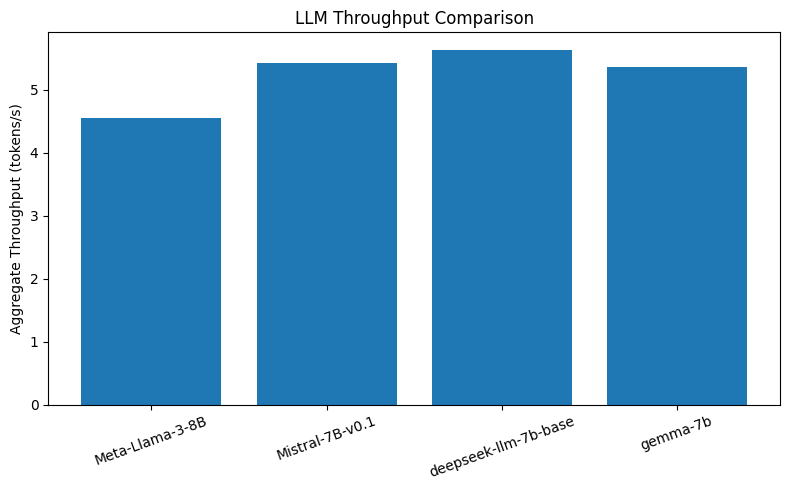

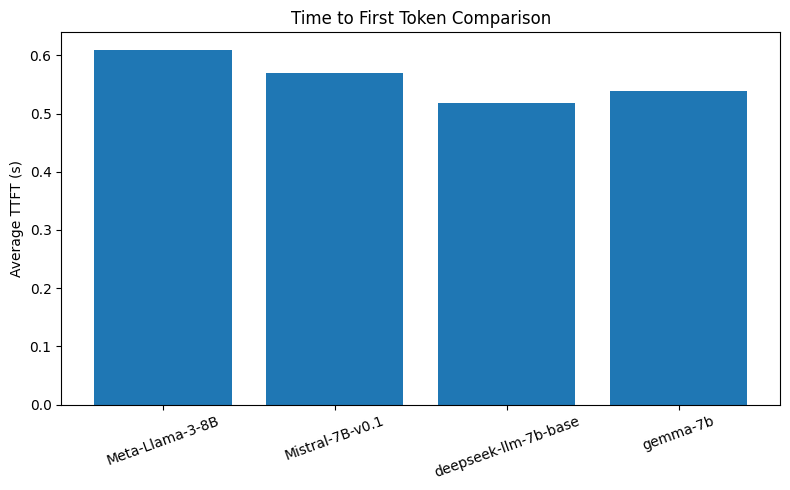

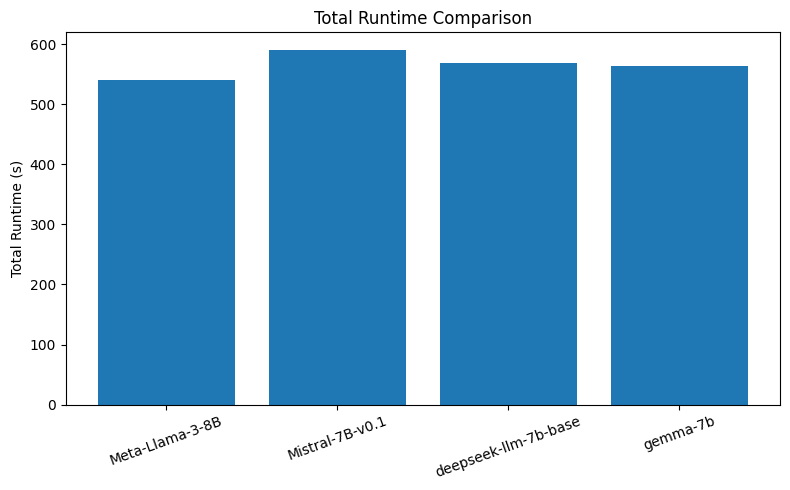

Saved plots:
 - throughput_comparison.png
 - ttft_comparison.png
 - runtime_comparison.png
 - efficiency plots (if available)
 - tradeoff scatter (if available)


In [1]:
#!/usr/bin/env python3

import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "aggregate_results.csv"

# -------------------------
# load + clean
# -------------------------
df = pd.read_csv(CSV_PATH)

# shorten names if needed
if "model_short" not in df.columns:
    df["model_short"] = df["model"].apply(
        lambda x: x.split("/")[-1] if isinstance(x, str) else x
    )

# sort for consistent plots
df = df.sort_values("model_short")

# -------------------------
# helper
# -------------------------
def bar_plot(metric, ylabel, title, fname):
    plt.figure(figsize=(8, 5))
    plt.bar(df["model_short"], df[metric])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(fname, dpi=300)
    plt.show()

# -------------------------
# performance plots
# -------------------------

# Throughput
bar_plot(
    metric="aggregate_tokens_per_sec",
    ylabel="Aggregate Throughput (tokens/s)",
    title="LLM Throughput Comparison",
    fname="throughput_comparison.png"
)

# TTFT
bar_plot(
    metric="avg_ttft_s",
    ylabel="Average TTFT (s)",
    title="Time to First Token Comparison",
    fname="ttft_comparison.png"
)

# Runtime
bar_plot(
    metric="seconds",
    ylabel="Total Runtime (s)",
    title="Total Runtime Comparison",
    fname="runtime_comparison.png"
)

# -------------------------
# efficiency plots (if available)
# -------------------------
if "tokens_per_joule" in df.columns and df["tokens_per_joule"].notna().any():
    bar_plot(
        metric="tokens_per_joule",
        ylabel="Tokens / Joule",
        title="Energy Efficiency Comparison",
        fname="tokens_per_joule_comparison.png"
    )

if "energy_per_token_j" in df.columns and df["energy_per_token_j"].notna().any():
    bar_plot(
        metric="energy_per_token_j",
        ylabel="Energy / Token (J)",
        title="Energy per Token Comparison",
        fname="energy_per_token_comparison.png"
    )

# -------------------------
# tradeoff scatter
# -------------------------
if (
    "aggregate_tokens_per_sec" in df.columns
    and "energy_per_token_j" in df.columns
    and df["energy_per_token_j"].notna().any()
):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        df["aggregate_tokens_per_sec"],
        df["energy_per_token_j"],
        s=100
    )

    for _, row in df.iterrows():
        plt.text(
            row["aggregate_tokens_per_sec"],
            row["energy_per_token_j"],
            row["model_short"],
            fontsize=9
        )

    plt.xlabel("Aggregate Throughput (tokens/s)")
    plt.ylabel("Energy / Token (J)")
    plt.title("Performance vs Energy Tradeoff")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("throughput_vs_energy_tradeoff.png", dpi=300)
    plt.show()

print("Saved plots:")
print(" - throughput_comparison.png")
print(" - ttft_comparison.png")
print(" - runtime_comparison.png")
print(" - efficiency plots (if available)")
print(" - tradeoff scatter (if available)")

In [ ]:
#!/usr/bin/env python3

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "aggregate_results.csv"
LOG_ROOT = "logs"

# -------------------------
# load aggregate data
# -------------------------
df = pd.read_csv(CSV_PATH)

if "model_short" not in df.columns:
    df["model_short"] = df["model"].apply(
        lambda x: x.split("/")[-1] if isinstance(x, str) else x
    )

df = df.sort_values("model_short")

# -------------------------
# helper for power csv
# -------------------------
def load_power_trace(run_dir):
    power_csv = os.path.join(run_dir, "power.csv")

    if not os.path.exists(power_csv):
        return None

    pdf = pd.read_csv(power_csv)
    pdf.columns = pdf.columns.str.strip()

    pdf["timestamp"] = pd.to_datetime(pdf["timestamp"])

    # relative seconds from start
    pdf["t"] = (pdf["timestamp"] - pdf["timestamp"].iloc[0]).dt.total_seconds()

    # clean power values
    pdf["power_w"] = (
        pdf["power.draw [W]"]
        .str.replace(" W", "", regex=False)
        .astype(float)
    )

    return pdf


# -------------------------
# overlay power traces
# -------------------------
plt.figure(figsize=(10, 6))

plotted = False

for _, row in df.iterrows():
    run_dir = row["run_dir"]

    pdf = load_power_trace(run_dir)

    if pdf is None:
        continue

    plt.plot(
        pdf["t"],
        pdf["power_w"],
        label=row["model_short"],
        linewidth=2
    )
    plotted = True

if plotted:
    plt.xlabel("Time (s)")
    plt.ylabel("Power (W)")
    plt.title("GPU Power Trace During LLM Inference")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("power_trace_overlay.png", dpi=300)
    plt.show()
else:
    print("No power traces found.")


# -------------------------
# average power comparison
# -------------------------
if "avg_power_w" in df.columns and df["avg_power_w"].notna().any():
    plt.figure(figsize=(8, 5))
    plt.bar(df["model_short"], df["avg_power_w"])
    plt.ylabel("Average Power (W)")
    plt.title("Average GPU Power by Model")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("avg_power_comparison.png", dpi=300)
    plt.show()


# -------------------------
# energy comparison
# -------------------------
if "energy_total_j" in df.columns and df["energy_total_j"].notna().any():
    plt.figure(figsize=(8, 5))
    plt.bar(df["model_short"], df["energy_total_j"])
    plt.ylabel("Total Energy (J)")
    plt.title("Total Energy Consumption by Model")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("energy_total_comparison.png", dpi=300)
    plt.show()


print("Saved:")
print(" - power_trace_overlay.png")
print(" - avg_power_comparison.png (if data exists)")
print(" - energy_total_comparison.png (if data exists)")